# X-bar 管制圖 ARL₀ 模擬

## 研究目的

Average Run Length, ARL 是衡量管制圖偵測能力的重要指標。 ARL₀ 表示製程處於 In-Control 時，平均需要觀察多少個 subgroup 才會第一次出現超出管制界限的訊號。

理論上，若使用 3-Sigma 管制界限，其誤警報機率約為：

$P(|Z|>3)=0.0027$

因此理論 ARL₀ 為：

$ARL_0=\frac{1}{0.0027}\approx370$

本研究利用 Monte Carlo Simulation 模擬 X-bar 管制圖，估計其 ARL₀ 並與理論值進行比較。

## 模擬設定與方法

假設製程資料服從標準常態分配：

$$X \sim N(0,1)$$

設定參數如下：

- 製程平均數：$\mu_0=0$
- 製程標準差：$\sigma_0=1$
- subgroup size：$n=5$
- 模擬次數：$k=10000$

X-bar 管制圖的管制界限設定如下：

$$UCL=\mu_0+\frac{3\sigma_0}{\sqrt n}$$
$$CL=\mu_0$$
$$LCL=\mu_0-\frac{3\sigma_0}{\sqrt n}$$

模擬流程如下：

1. 從 $N(0,1)$ 中隨機抽取 n=5 個樣本。
2. 計算 subgroup 平均數 $\bar X$。
3. 判斷是否超出管制界限。
4. 若未超出界限，則持續產生下一個 subgroup。
5. 若超出界限，則記錄該次 Run Length。
6. 重複上述程序 10000 次。
7. 將所有 Run Length 取平均得到 ARL₀。

In [1]:
import numpy as np

# 固定亂數種子
np.random.seed(123)

def simulate_ARL0_xbar(mu0=0, sigma0=1, n=5, k=10000):

    # 建立管制界限
    UCL = mu0 + 3 * sigma0 / np.sqrt(n)
    LCL = mu0 - 3 * sigma0 / np.sqrt(n)

    run_lengths = []

    # 重複模擬 k 次
    for _ in range(k):

        rl = 0

        while True:

            # 產生 subgroup
            sample = np.random.normal(
                loc=mu0,
                scale=sigma0,
                size=n
            )

            # 計算 subgroup 平均
            xbar = np.mean(sample)

            rl += 1

            # 判斷是否超出管制界限
            if xbar > UCL or xbar < LCL:
                break

        run_lengths.append(rl)

    return np.mean(run_lengths), run_lengths


ARL0, run_lengths = simulate_ARL0_xbar()

print(f"模擬得到的 ARL₀ = {ARL0:.3f}")

模擬得到的 ARL₀ = 370.188


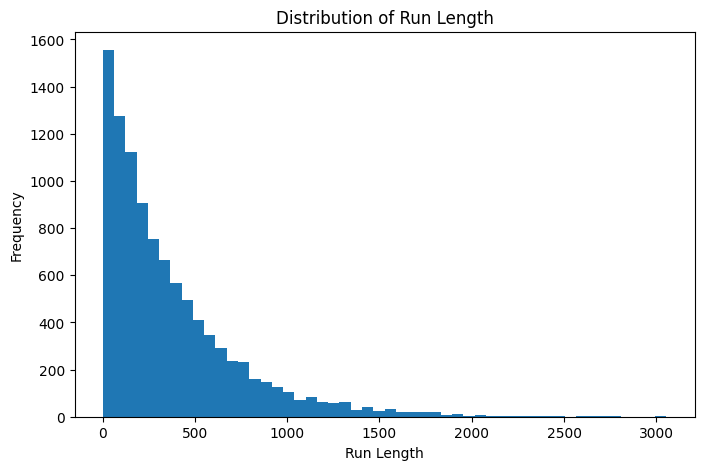

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(run_lengths, bins=50)

plt.xlabel("Run Length")
plt.ylabel("Frequency")
plt.title("Distribution of Run Length")

plt.show()

## 模擬結果與討論

本研究利用 Monte Carlo Simulation 重複模擬 10000 次 X-bar 管制圖的監控過程，計算得到 ARL₀。

模擬結果顯示 ARL₀ 約為 370 左右，與理論值 370 相當接近。

此結果表示當製程維持在管制狀態時，平均約每 370 個 subgroup 才會出現一次超出管制界限的訊號，因此該訊號可視為誤警報（False Alarm）。

從 Run Length 分布圖可以發現，大部分 Run Length 集中於較小區域，但仍有部分較大的 Run Length，因此整體呈現右偏分布。這是因為 Run Length 本質上與幾何分布的特性相似，具有長尾現象。

## 結論

本研究透過 Monte Carlo Simulation 估計 X-bar 管制圖的 ARL₀。在製程資料服從標準常態分配且採用三倍標準差管制界限的情況下，模擬得到的 ARL₀ 約為 370，與理論值一致，驗證了 X-bar 管制圖在 In-Control 狀態下的特性。